# Evaluating Model on Unseen Data

# Tools and Utils

In [2]:
# ----import tools----

#Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, load_dataset
from huggingface_hub import login

# MLflow
import mlflow
import mlflow.transformers
from mlflow.tracking import MlflowClient

#text processing
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)


# Tensorflow and Keras and torch
import tensorflow as tf
import numpy as np
import torch
from torch.utils.data import DataLoader

#evaluation
import evaluate
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# I. Fetch Test Data

In [3]:
# load the data set
test_ds = Dataset.from_file('../data/processed/test_ds/data-00000-of-00001.arrow')
test_ds.to_pandas()['labels'].value_counts()

labels
fraud    1324
ham      1286
Name: count, dtype: int64

In [4]:
test_ds.to_pandas().head()

,text,labels
0,Important notice: Your prize claim requires ur...,fraud
1,Secure a free laptop! right away and enjoy exc...,ham
2,Important notice: Your prize claim requires ur...,fraud
3,Then ü ask dad to pick ü up lar... Ü wan 2 sta...,ham
4,"smallcap investment opportunity\n\ndrummond ,\...",fraud


# II.Load model from MLflow

In [5]:
# set tracking uri
mlflow.set_tracking_uri("http://localhost:8080")
# load the model and tokenizer from mlflow
model_run_id = "models:/m-939f3b944fa7474183c04f6c020c2665"

# load component from mlflow
components = mlflow.transformers.load_model(model_run_id)
lora_mbert= components.model
tokenizer = components.tokenizer

2026/05/18 11:30:08 INFO mlflow.transformers: 'models:/m-939f3b944fa7474183c04f6c020c2665' resolved as 'mlflow-artifacts:/1/models/m-939f3b944fa7474183c04f6c020c2665/artifacts'


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


### Tokenize

In [6]:
# Encode data
labels2id = {"fraud":1,"ham":0}
encoded_test_ds = test_ds.map(lambda x: {"labels": labels2id[x['labels']]})

# tokenize the data set
tokenized_ds = encoded_test_ds.map(
    lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=256),
    batched=True,
)

tokenized_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(tokenized_ds.features)
print(tokenized_ds)

{'text': Value('string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2610
})


# I. Evaluate Inference Performance

In [7]:
import time
from transformers import DataCollatorWithPadding
"""
#Initialize the collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#Pass it to DataLoader
loader = DataLoader(
    tokenized_ds, 
    batch_size=4, 
    collate_fn=data_collator  # This handles the variable lengths
)
"""

#MPS
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# inferance argss
loader = DataLoader(tokenized_ds, batch_size=4)
total_samples = 0
predictions = []
latencies = []
lora_mbert.eval() 

# predict the labels
with torch.no_grad():
    for batch in loader:
        # get the input_ids and attention_mask
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # make prediction
        start_time = time.time() 
        outputs = lora_mbert(input_ids=torch.tensor(input_ids), attention_mask=torch.tensor(attention_mask))
        logits = outputs.logits

        # preprocess output
        batch_predictions = torch.argmax(logits, dim=-1)
        end_time = time.time()

        #store the result
        predictions.extend(batch_predictions.cpu().tolist())
        latencies.append((end_time - start_time)*1000)

        #show progress and result
        print(f"progress:{len(predictions)}/{len(tokenized_ds)}")

#calculate throughput (sample/ms)
throughput = len(test_ds) / (np.sum(latencies) / 1000)

inference_metrics = {
    "p50_latency_ms": float(np.percentile(latencies, 50)),
    "p95_latency_ms": float(np.percentile(latencies, 95)),
    "p99_latency_ms": float(np.percentile(latencies, 99)),
    "throughput_req_sec": float(throughput)
}


/var/folders/tk/mn4_r_cn03ndtjss8b670dfw0000gn/T/ipykernel_1395/3955150590.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputs = lora_mbert(input_ids=torch.tensor(input_ids), attention_mask=torch.tensor(attention_mask))
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


progress:4/2610
progress:8/2610
progress:12/2610
progress:16/2610
progress:20/2610
progress:24/2610
progress:28/2610
progress:32/2610
progress:36/2610
progress:40/2610
progress:44/2610
progress:48/2610
progress:52/2610
progress:56/2610
progress:60/2610
progress:64/2610
progress:68/2610
progress:72/2610
progress:76/2610
progress:80/2610
progress:84/2610
progress:88/2610
progress:92/2610
progress:96/2610
progress:100/2610
progress:104/2610
progress:108/2610
progress:112/2610
progress:116/2610
progress:120/2610
progress:124/2610
progress:128/2610
progress:132/2610
progress:136/2610
progress:140/2610
progress:144/2610
progress:148/2610
progress:152/2610
progress:156/2610
progress:160/2610
progress:164/2610
progress:168/2610
progress:172/2610
progress:176/2610
progress:180/2610
progress:184/2610
progress:188/2610
progress:192/2610
progress:196/2610
progress:200/2610
progress:204/2610
progress:208/2610
progress:212/2610
progress:216/2610
progress:220/2610
progress:224/2610
progress:228/2610


   p50_latency_ms  p95_latency_ms  p99_latency_ms  throughput_req_sec
0        13.43298       23.080444       36.164751          231.500242


<Axes: >

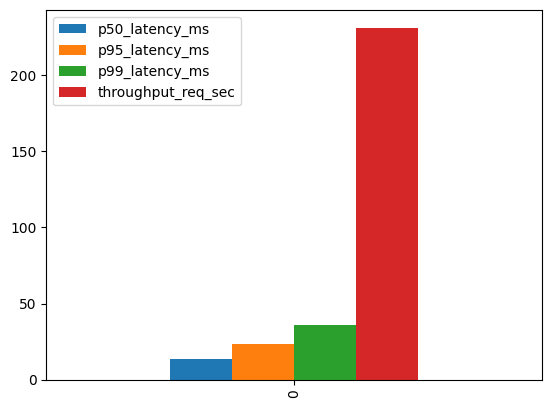

In [8]:
print(pd.DataFrame(inference_metrics, index=[0]))
pd.DataFrame(inference_metrics, index=[0]).plot(kind='bar')

# II. Evaluate Model Architecture

In [9]:
num_params = lora_mbert.num_parameters()
memory_size = lora_mbert.get_memory_footprint() / (1024**2)
width = lora_mbert.config.hidden_size
length = lora_mbert.config.num_hidden_layers

architecture_metrics = {
    "num_parameters": num_params,
    "model_width": width,
    "model_length": length,
    "memory_size_MB": memory_size,
}

pd.DataFrame(architecture_metrics, index=[0])

,num_parameters,model_width,model_length,memory_size_MB
0,136213252,768,6,519.616226


In [10]:
print("label vs prediction", list(zip(tokenized_ds["labels"], predictions)))

label vs prediction [(tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(0), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 0), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(1), 1), (tensor(0), 0), (tensor(0), 0), (tensor(1), 1), (te

# IV. Evaluate Performance

### Classification Report

In [20]:
pred_vs_actual = {"predictions":np.int8(predictions), 
                  "actual":np.int8(tokenized_ds["labels"])}
pred_vs_actual = pd.DataFrame(pred_vs_actual)

   accuracy  precision    recall  f1_score
0   0.97318   0.981567  0.965257  0.973343


<Axes: >

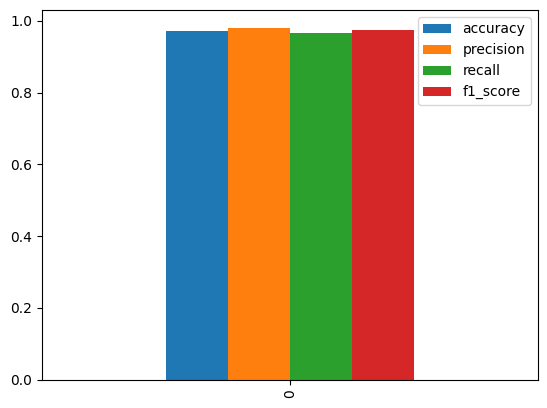

In [21]:
def compute_metrics(predictions, references):
    accuracy = accuracy_score(references, predictions)
    precision = precision_score(references, predictions)
    recall = recall_score(references, predictions)
    f1 = f1_score(references, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }

# compute metrics
references = pred_vs_actual['actual']
performance_metrics = compute_metrics(pred_vs_actual['predictions'], references)
print(pd.DataFrame(performance_metrics,index=[0]))
pd.DataFrame(performance_metrics,index=[0]).plot(kind='bar')

### Confusion Metric

[[0.98133748 0.01866252]
 [0.0347432  0.9652568 ]]


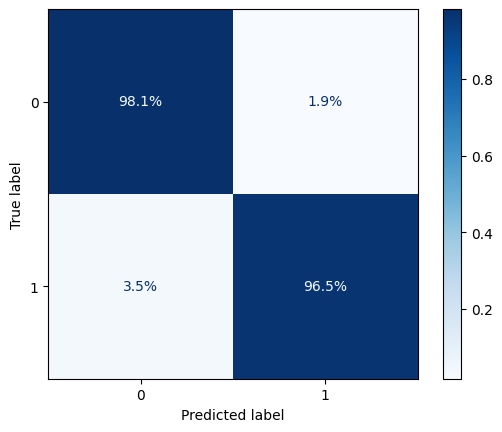

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 
cm = confusion_matrix(
    y_true=pred_vs_actual['actual'],
    y_pred=pred_vs_actual['predictions'],
    normalize='true'
)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, values_format='.1%')

# Print raw decimal values to the console
print(cm)
plt.show()


### Eror Analysis ()

In [16]:
false_pred = pred_vs_actual[pred_vs_actual["predictions"] != pred_vs_actual["actual"]]
false_pred.value_counts()

predictions  actual
0            1         46
1            0         24
Name: count, dtype: int64

In [17]:
print("---Samples of False Negative---")
fn = false_pred[(false_pred["actual"] == 1) & (false_pred["predictions"] == 0)]
test_df = test_ds.to_pandas()
fn_samples = test_df[test_df.index.isin(fn.index)]
fn_samples

---Samples of False Negative---


,text,labels
39,re : pretty girl wants to meet a real woman\n\...,fraud
171,Guess who am I?This is the first time I create...,fraud
184,Save �5.00 on Creamfields tickets\n\nCreamfiel...,fraud
195,Lose 11 Pounds In 7 Days IML...,fraud
209,TOMORROW -- Password: Soleil -- TV Casting\n\n...,fraud
244,"re : sun , 2 may 2004 23 : 25 : 27 - 0500\n\nm...",fraud
310,"how ya doin ? debit\n\nhey , my name is amber ...",fraud
385,[SA] Nice web page templates here. Check it ou...,fraud
517,Filter Film Capacitor\n\nThis is a multi-part ...,fraud
529,You will be receiving this week's Triple Echo ...,fraud


In [18]:
import spacy
from collections import Counter

# Load spaCy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def analyze_fraud_characteristics(df, label_col, n=20):
    # 1. Filter for fraud and process text
    fraud_text = " ".join(df[df[label_col] == 'fraud']['text'].astype(str))
    doc = nlp(fraud_text[:1000000]) # Stay under 1M character limit
    
    # 2. Get Lemmas (Root words) to catch characteristics like 'winning' vs 'win'
    lemmas = [
        token.lemma_.lower() for token in doc 
        if not token.is_stop and not token.is_punct and token.is_alpha
    ]
    
    # 3. Get Bigrams (2-word phrases) to find characteristic "scripts"
    bigrams = [f"{lemmas[i]} {lemmas[i+1]}" for i in range(len(lemmas)-1)]
    
    return {
        "top_themes": Counter(lemmas).most_common(n),
        "top_phrases": Counter(bigrams).most_common(n)
    }

# Run the analysis
results = analyze_fraud_characteristics(fn_samples, 'labels')

print("--- TOP FRAUD THEMES (Root Words) ---")
for word, count in results['top_themes']:
    print(f"{word}: {count}")

print("\n--- TOP FRAUD PHRASES (Scripts) ---")
for phrase, count in results['top_phrases']:
    print(f"{phrase}: {count}")

--- TOP FRAUD THEMES (Root Words) ---
de: 35
e: 22
s: 20
company: 19
m: 18
o: 18
r: 17
gas: 17
t: 16
p: 16
x: 15
foot: 15
time: 14
say: 13
information: 13
lose: 13
message: 13
g: 13
oil: 13
new: 12

--- TOP FRAUD PHRASES (Scripts) ---
company s: 9
source say: 7
mini plant: 7
e r: 6
de produccion: 6
smart card: 6
http www: 6
extreme power: 5
power plus: 5
oil gas: 5
military source: 4
lose weight: 4
help lose: 4
content type: 4
r m: 4
g opill: 4
plant mobile: 4
mobile container: 4
financial news: 4
science network: 4


### Per Class Performance (Classification Report)

### 

# Evaluating Model's Features Importance

### SHAP

In [20]:
import torch
import shap
import numpy as np

# FORCE CPU
device = torch.device("cpu")

# Move model fully to CPU
lora_mbert = lora_mbert.to(device)

# Important
lora_mbert.eval()

# Prediction function
def predict_logits(texts):

    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    texts = [str(x) for x in texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    # FORCE CPU tensors
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = lora_mbert(**inputs)

    return outputs.logits.detach().cpu().numpy()


# SHAP masker
masker = shap.maskers.Text(tokenizer)

# Explainer
explainer = shap.Explainer(
    predict_logits,
    masker
)

# Clean text
text_samples = (
    test_df["text"].sample(3).fillna("").astype(str).tolist()
)

# SMALL batch first
shap_values = explainer(text_samples)

PartitionExplainer explainer:  67%|██████▋   | 2/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:18,  9.16s/it]               


In [67]:
shap.plots.text(shap_values[0, :, 1])

### SHAP on FAlSE NEGATIVE

In [21]:
fn_text_samples = fn_samples['text'].sample(3).astype(str).tolist()
shap_values_fn = explainer(fn_text_samples)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (722 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [01:11<00:00,  2.34s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [01:18, 26.10s/it]                       


In [98]:
shap.plots.text(shap_values_fn[2, :, 1])

# Cosine Similarity between FN with TN 

In [23]:
# preprocess data
fn_samples
ham_samples = test_df[test_df['labels'] == 'ham'].sample(len(fn_samples))
print(len(ham_samples))
print(len(fn_samples))

46
46


In [24]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def false_negative_vs_ham_similarity(model_url, false_negative_samples, actual_ham_samples,similar_label_threshold=0.90):
    # 1. Load model
    model = SentenceTransformer(model_url)

    # 2. Encode FN samples
    fn_embeddings = model.encode(
        false_negative_samples['text']
        .astype(str)
        .fillna("")
        .tolist(),
        show_progress_bar=True
    )

    # 3. Encode actual ham samples
    ham_embeddings = model.encode(
        actual_ham_samples['text']
        .astype(str)
        .fillna("")
        .tolist(),
        show_progress_bar=True
    )

    # 4. Cosine similarity matrix
    sim_matrix = cosine_similarity(fn_embeddings, ham_embeddings)

    # 5. Average similarity
    avg_similarity = np.mean(sim_matrix)

    # 6. Find highly similar pairs
    high_sim_pairs = np.where(sim_matrix > similar_label_threshold)

    # 7. Make readable output
    readable_pairs = []

    for fn_i, ham_i in zip(*high_sim_pairs):

        readable_pairs.append({
            "false_negative_text":
                false_negative_samples.iloc[fn_i]['text'],

            "ham_text":
                actual_ham_samples.iloc[ham_i]['text'],

            "similarity":
                float(sim_matrix[fn_i, ham_i])
        })

    return {
        "average_similarity": float(avg_similarity),
        "high_similarity_pairs": readable_pairs,
        "num_false_negative_samples": len(false_negative_samples),
        "num_actual_ham_samples": len(actual_ham_samples)
    }

similarity = false_negative_vs_ham_similarity(model_url="all-MiniLM-L6-v2", 
                                       actual_ham_samples=ham_samples,
                                       false_negative_samples=fn_samples,
                                       similar_label_threshold=0.13)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [25]:
similarity['average_similarity']

0.10266276448965073

In [26]:
similarity['high_similarity_pairs']

[{'false_negative_text': 're : pretty girl wants to meet a real woman\n\nremove\nminnesota , which can clinch a wild - card\nplayoff spot with a loss by either carolina or st . louis this weekend , appeared on\nits way to retaking the lead . but a holding penalty on birk - - the vikings were\nflagged nine times for 78 yards - - wiped out a 16 - yard run by michael bennett that\nwould have given them the ball at the green bay 40 just before the 2 - minute warning .\nthe vikings ( 8 - 7 ) , though , couldn \' t\nget what they needed from a pass defense that has struggled all season .\ngovernment spokesman raanan gissin\nsaid four soldiers were killed .\nsix people were taken to hospital - -\nfour badly hurt , one with moderate injuries and one lightly injured , military\nsources said .\nthe sources said another soldier\nremained beneath the rubble .\ngissin said rescue operations were\ncontinuing sunday night .\nthe attack " indicates that unless\nthere is decisive and sustained effort t

# Logging Test Result

In [28]:
# config
mlflow.set_tracking_uri("http://localhost:8080")
mlflow.set_experiment("scam-detector-finetuning")
run_id = "bf1a1dd415d741baa0783d07e4dbaca6"

test_metrics = {"test_accuracy": performance_metrics['accuracy'],
                "test_precision": performance_metrics['precision'],
                "test_recall": performance_metrics['recall'],
                "test_f1_score": performance_metrics['f1_score']}

with mlflow.start_run(run_id=run_id) as run:
    # log inference metrics
    mlflow.log_metrics(inference_metrics)
    # log architecture metrics
    mlflow.log_metrics(architecture_metrics)
    # log performance metrics
    mlflow.log_metrics(test_metrics)
    # log confusion matrix plot
    mlflow.log_figure(disp.figure_, "confusion_matrix.png")
    #set tag
    mlflow.set_tag("model_name", "lora_distilmBERT_v2")


🏃 View run lora_distilmBERT_v2 at: http://localhost:8080/#/experiments/1/runs/bf1a1dd415d741baa0783d07e4dbaca6
🧪 View experiment at: http://localhost:8080/#/experiments/1
